In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
import seaborn as sns
from generating_dataset import dataset,true_beta
from palette import palette

In [13]:
X,y = dataset
n,p = X.shape[0],X.shape[1]-1

### <b> EXPERIMENT 7.2.1 Non Informative vs Frequentist

In [14]:
XtX = X.T @ X
inv_XtX = np.linalg.inv(XtX)
beta_ols = inv_XtX @ X.T @ y
SSE = np.sum((y - X @ beta_ols)**2)

# A) Jeffreys Indep / Sampling distribution OLS
a1_ind = (n-(p+1)) / 2.0
b1_ind = SSE / 2.0
df_ind = 2*a1_ind
mean_ind = beta_ols
sd_ind = np.sqrt((b1_ind / a1_ind) * np.diag(inv_XtX))

# B) Jeffreys Prior
a1_joint = n / 2.0
b1_joint = SSE / 2.0
df_joint = 2*a1_joint
mean_joint = beta_ols
sd_joint = np.sqrt((b1_joint / a1_joint) * np.diag(inv_XtX))

# C) Zellner's g-Prior (Unit Information Prior: g = n = 100, mu_0 = 0) (a_0,b_0=0)
g = n
a_0 = 0
b_0 = 0
a1_g = a_0 + n / 2.0  
V1_g = (g / (g + 1)) * inv_XtX
df_g = 2*a1_g
mean_g = (g / (g + 1)) * beta_ols #mu_0 = 0

b_star = b_0 + SSE / 2.0 + (1 / (2 * (g + 1))) * (beta_ols.T @ XtX @ beta_ols) #mu_0 = 0
sd_g = np.sqrt((b_star / a1_g) * np.diag(V1_g))


### <b> Posterior distributions

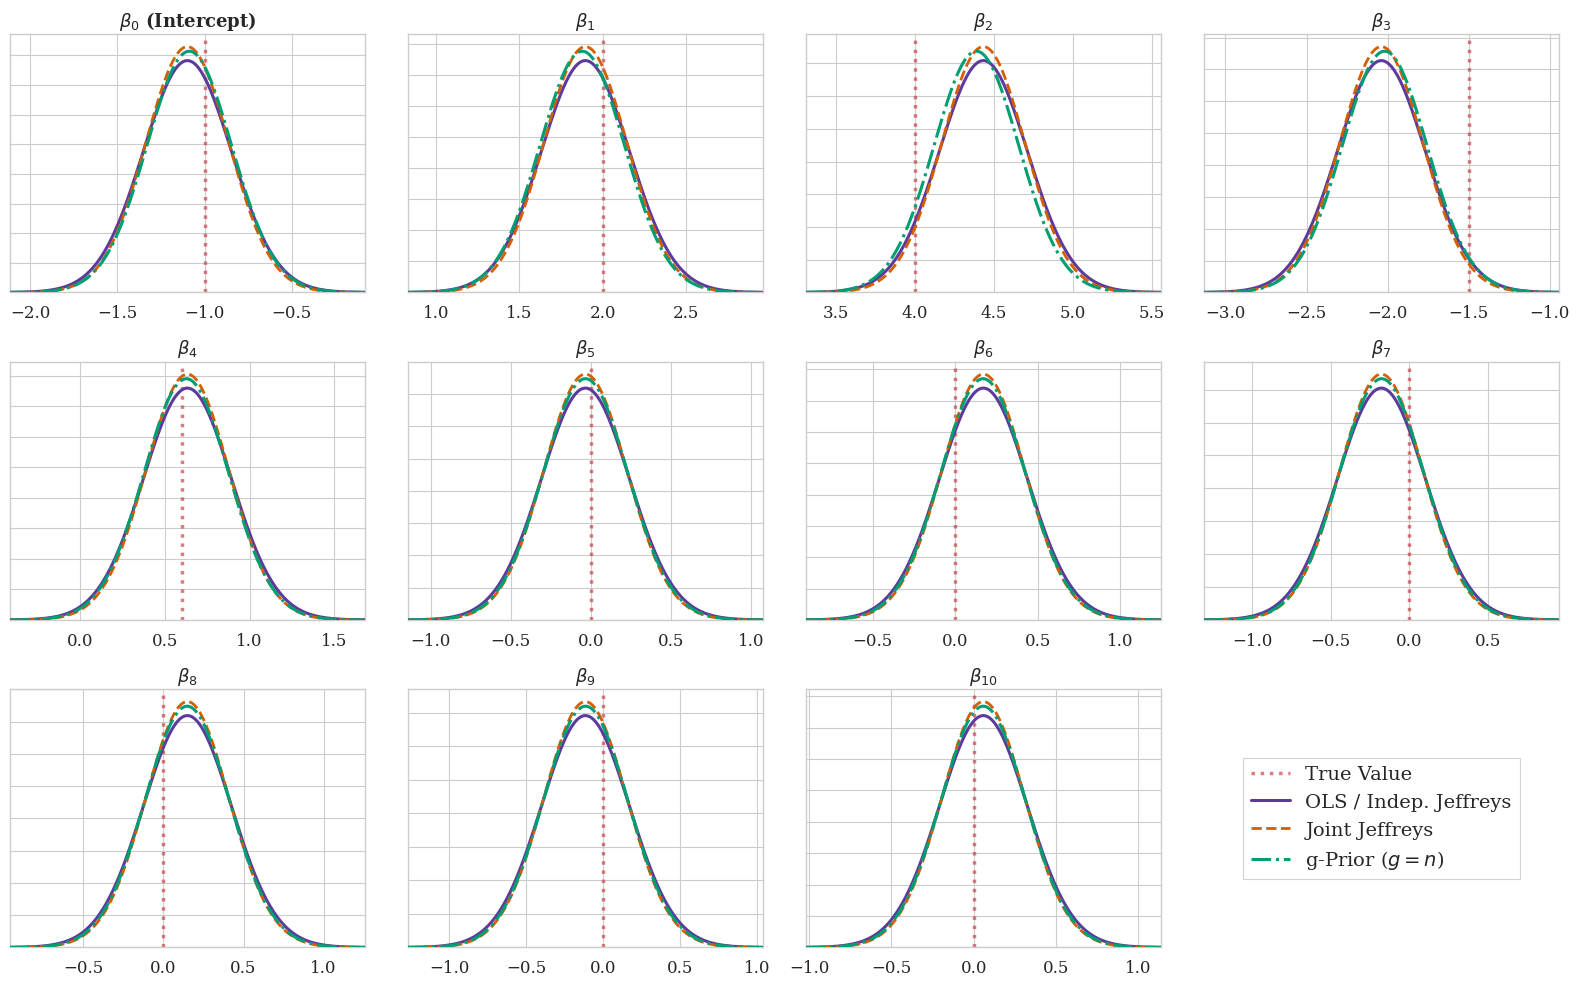

In [15]:
sns.set_theme(style="whitegrid", context="paper", font="serif")
plt.rcParams.update({'font.size': 11, 'axes.titleweight': 'bold'})

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for i in range(p + 1):
    ax = axes[i]
    
    x_min = mean_ind[i] - 4.0 * sd_ind[i]
    x_max = mean_ind[i] + 4.0 * sd_ind[i]
    x_rango = np.linspace(x_min, x_max, 500)
    
    # Density functions
    pdf_ind = t.pdf(x_rango, df=df_ind, loc=mean_ind[i], scale=sd_ind[i])
    pdf_joint = t.pdf(x_rango, df=df_joint, loc=mean_joint[i], scale=sd_joint[i])
    pdf_g = t.pdf(x_rango, df=df_g, loc=mean_g[i], scale=sd_g[i])
    
    # True value lines
    ax.axvline(true_beta[i], color=palette.true_red, linestyle=':', linewidth=2.5, 
               alpha=0.6, zorder=1, label='True Value')
    
    # Plot density functions
    ax.plot(x_rango, pdf_ind, color=palette.ols, linewidth=2.2, zorder=3, label='OLS / Indep. Jeffreys') 
    ax.plot(x_rango, pdf_joint, color=palette.joint, linestyle='--', linewidth=2, zorder=3, label='Joint Jeffreys') 
    ax.plot(x_rango, pdf_g, color=palette.gprior, linestyle='-.', linewidth=2.2, zorder=3, label='g-Prior ($g=n$)')
    
    
    
    titulo = f"$\\boldsymbol{{\\beta_{{{i}}}}}$ (Intercept)" if i == 0 else f"$\\boldsymbol{{\\beta_{{{i}}}}}$"
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_ylim(bottom=0)
    ax.set_xlim(x_min, x_max) 
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelleft=False)  # Hide y-axis labels but keep grid



# Legend setup
handles, labels = axes[0].get_legend_handles_labels()

ax_legend = axes[-1]
ax_legend.axis('off')
ax_legend.legend(handles, labels, 
                 loc='center', 
                 fontsize=14, 
                 frameon=True,          
                 fancybox=False,        
                 edgecolor='#D3D3D3',   
                 facecolor='white',      
                 framealpha=1)          

plt.tight_layout()
plt.savefig("../graphics/non_informative_priors_vs_ols.pdf", dpi=300, bbox_inches='tight')
plt.show()

### <b> Credible intervals

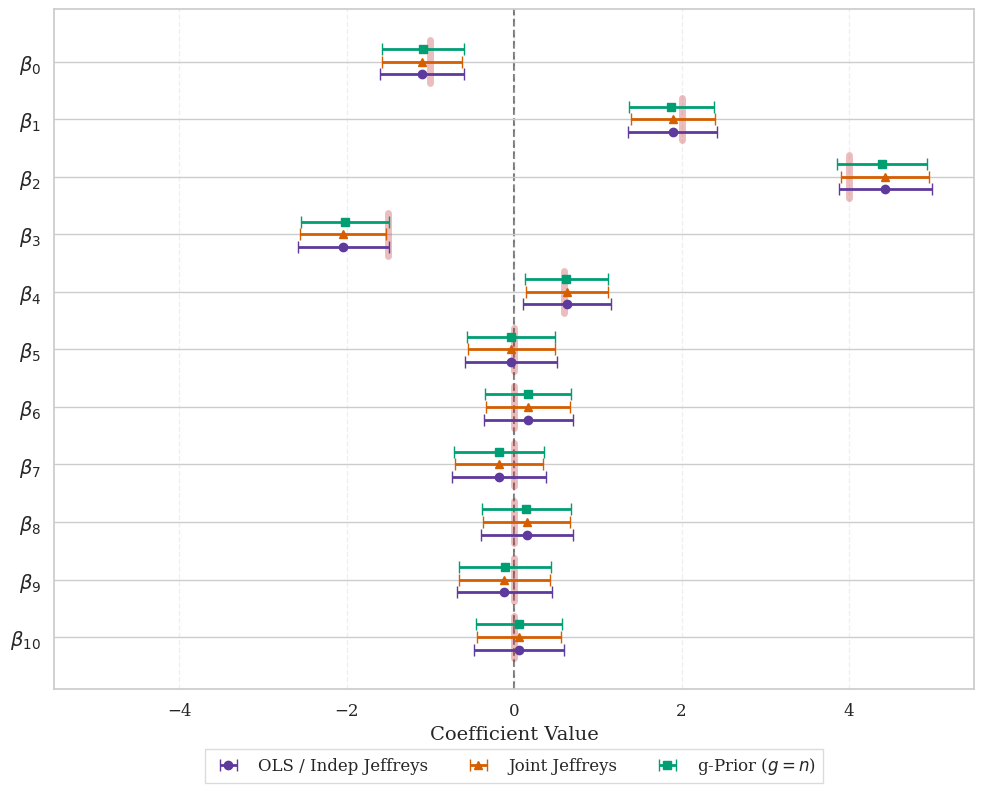

In [16]:
sns.set_theme(style="whitegrid", font="serif")

fig, ax = plt.subplots(figsize=(10, 8))

# 0.975 percentile
me_ind = t.ppf(0.975, df=df_ind) * sd_ind
me_joint = t.ppf(0.975, df=df_joint) * sd_joint
me_g = t.ppf(0.975, df=df_g) * sd_g



y_pos = np.arange(p + 1)
offset = 0.22 

# True beta
for i in range(p + 1):
    ax.plot([true_beta[i], true_beta[i]], [y_pos[i]-offset-0.15, y_pos[i]+offset+0.15], 
             color=palette.true_red, alpha=0.3, linewidth=5, zorder=1)

# Credible intervals
ax.errorbar(mean_ind, y_pos + offset, xerr=me_ind, fmt='o', color=palette.ols, linewidth=2, capsize=4, label='OLS / Indep Jeffreys')
ax.errorbar(mean_joint, y_pos, xerr=me_joint, fmt='^', color=palette.joint, linewidth=2, capsize=4, label='Joint Jeffreys')
ax.errorbar(mean_g, y_pos - offset, xerr=me_g, fmt='s', color=palette.gprior, linewidth=2, capsize=4, label=f'g-Prior ($g=n$)')

ax.axvline(0, color=palette.zero_gray, linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)


ax.set_yticks(y_pos)
ax.set_yticklabels([f"$\\boldsymbol{{\\beta_{{{i}}}}}$" for i in range(p + 1)], fontsize=14)
ax.invert_yaxis()


ax.set_xlabel("Coefficient Value", fontsize=14)
ax.tick_params(axis='x', labelsize=12)

# Dynamic X-axis limits
limit_r = max(np.max(np.abs(np.concatenate([mean_ind+me_ind, mean_ind-me_ind]))), 
              np.max(np.abs(np.concatenate([mean_g+me_g, mean_g-me_g]))))
ax.set_xlim(-limit_r * 1.1, limit_r * 1.1)
ax.grid(alpha=0.3, axis='x', linestyle='--')

# Legend
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=12, 
           frameon=True, edgecolor='#D3D3D3', fancybox=False)


plt.tight_layout()
plt.savefig("../graphics/non_informative_priors_vs_ols_ci.pdf", dpi=300, bbox_inches='tight')
plt.show()